# Tutorial 4 — Difficulty Dependence

Tests whether each measure changes as task difficulty changes. A good metacognitive
measure should be difficulty-independent. Replicates Rahnev (2025) Supp Tables 3–5.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from metasignal import stdpy

MEASURE_NAMES = [
    "meta-d'", "AUC2", "Gamma", "Phi", "DeltaConf",
    "M-Ratio", "AUC2-Ratio", "Gamma-Ratio", "Phi-Ratio", "DeltaConf-Ratio",
    "M-Diff", "AUC2-Diff", "Gamma-Diff", "Phi-Diff", "DeltaConf-Diff",
    "metaNoise", "metaUncertainty", "d'", "c", "mean_conf",
    "logL", "AIC", "BIC", "AICc", "k", "n",
]
N_MEAS = 26
n_ratings = 4
difficulty = (0.65, 0.75, 0.85)   # hard, medium, easy

def simulate_subject(seed, difficulty_levels=(0.65, 0.75, 0.85), n_per_level=80):
    r = np.random.default_rng(seed)
    trials = []
    for acc in difficulty_levels:
        stim    = r.choice([0, 1], n_per_level)
        resp    = np.where(r.random(n_per_level) < acc, stim, 1 - stim)
        correct = stim == resp
        conf    = np.where(
            correct,
            r.integers(3, n_ratings + 1, n_per_level),
            r.integers(1, 3, n_per_level),
        )
        trials.append((stim, resp, conf))
    return trials

n_subjects = 20
dataset = [simulate_subject(i) for i in range(n_subjects)]
print(f"Simulated {n_subjects} subjects × {len(difficulty)} difficulty levels")


Simulated 20 subjects × 3 difficulty levels


## Compute measures per difficulty level

In [2]:
n_levels = len(difficulty)
raw = np.full((n_subjects, n_levels, N_MEAS), np.nan)

for s_idx, subject_trials in enumerate(dataset):
    for lv_idx, (stim, resp, conf) in enumerate(subject_trials):
        raw[s_idx, lv_idx] = stdpy.compute_all_measures(
            stim, resp, conf, n_ratings=n_ratings
        )

print("Computed array shape:", raw.shape)


Computed array shape: (20, 3, 26)


## 3-SD outlier removal

Values beyond 3 SD per measure/level
are set to NaN, then propagated across all levels for that subject.

In [3]:
def remove_3sd_outliers(arr):
    out = arr.copy()
    _, n_lev, n_meas = out.shape
    for m in range(n_meas):
        for lv in range(n_lev):
            col = out[:, lv, m]
            mu, sd = np.nanmean(col), np.nanstd(col, ddof=1)
            if not np.isnan(mu) and sd > 0:
                out[(col < mu - 3*sd) | (col > mu + 3*sd), lv, m] = np.nan
        bad = np.isnan(out[:, :, m]).any(axis=1)
        out[bad, :, m] = np.nan
    return out

clean = remove_3sd_outliers(raw)
removed = int(np.sum(np.isnan(clean) & ~np.isnan(raw)))
print(f"Values set to NaN by 3-SD removal: {removed}")


Values set to NaN by 3-SD removal: 26


## One-sample t-test: easy − hard

In [4]:
def ttest_1samp(data):
    x = np.asarray(data, float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan, np.nan
    t, p = stats.ttest_1samp(x, 0)
    return t, n - 1, p, t / np.sqrt(n)

delta = clean[:, 2, :] - clean[:, 0, :]   # easy − hard

print(f"{'Measure':<20} {'t':>8} {'p':>10} {'d':>8} {'sig':>4}")
print("-" * 55)
for m, name in enumerate(MEASURE_NAMES):
    t, df, p, d = ttest_1samp(delta[:, m])
    if np.isnan(t):
        continue
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{name:<20} {t:8.3f} {p:10.4f} {d:8.3f} {stars:>4}")


Measure                     t          p        d  sig
-------------------------------------------------------
meta-d'                -0.370     0.7153   -0.083     
Phi                   -10.825     0.0000   -2.483  ***
DeltaConf               1.285     0.2142    0.287     
M-Ratio                -8.960     0.0000   -2.055  ***
AUC2-Ratio            -12.400     0.0000   -2.773  ***
Gamma-Ratio            -8.038     0.0000   -1.844  ***
Phi-Ratio              -7.944     0.0000   -1.822  ***
DeltaConf-Ratio        -8.063     0.0000   -1.850  ***
M-Diff                 -9.478     0.0000   -2.119  ***
AUC2-Diff             -12.657     0.0000   -2.830  ***
Gamma-Diff            -12.323     0.0000   -2.755  ***
Phi-Diff              -11.181     0.0000   -2.500  ***
DeltaConf-Diff         -9.984     0.0000   -2.233  ***
metaNoise               0.361     0.7223    0.081     
d'                     11.183     0.0000    2.501  ***
c                      -2.095     0.0498   -0.468    *
mean_conf

## Visualise difficulty effect

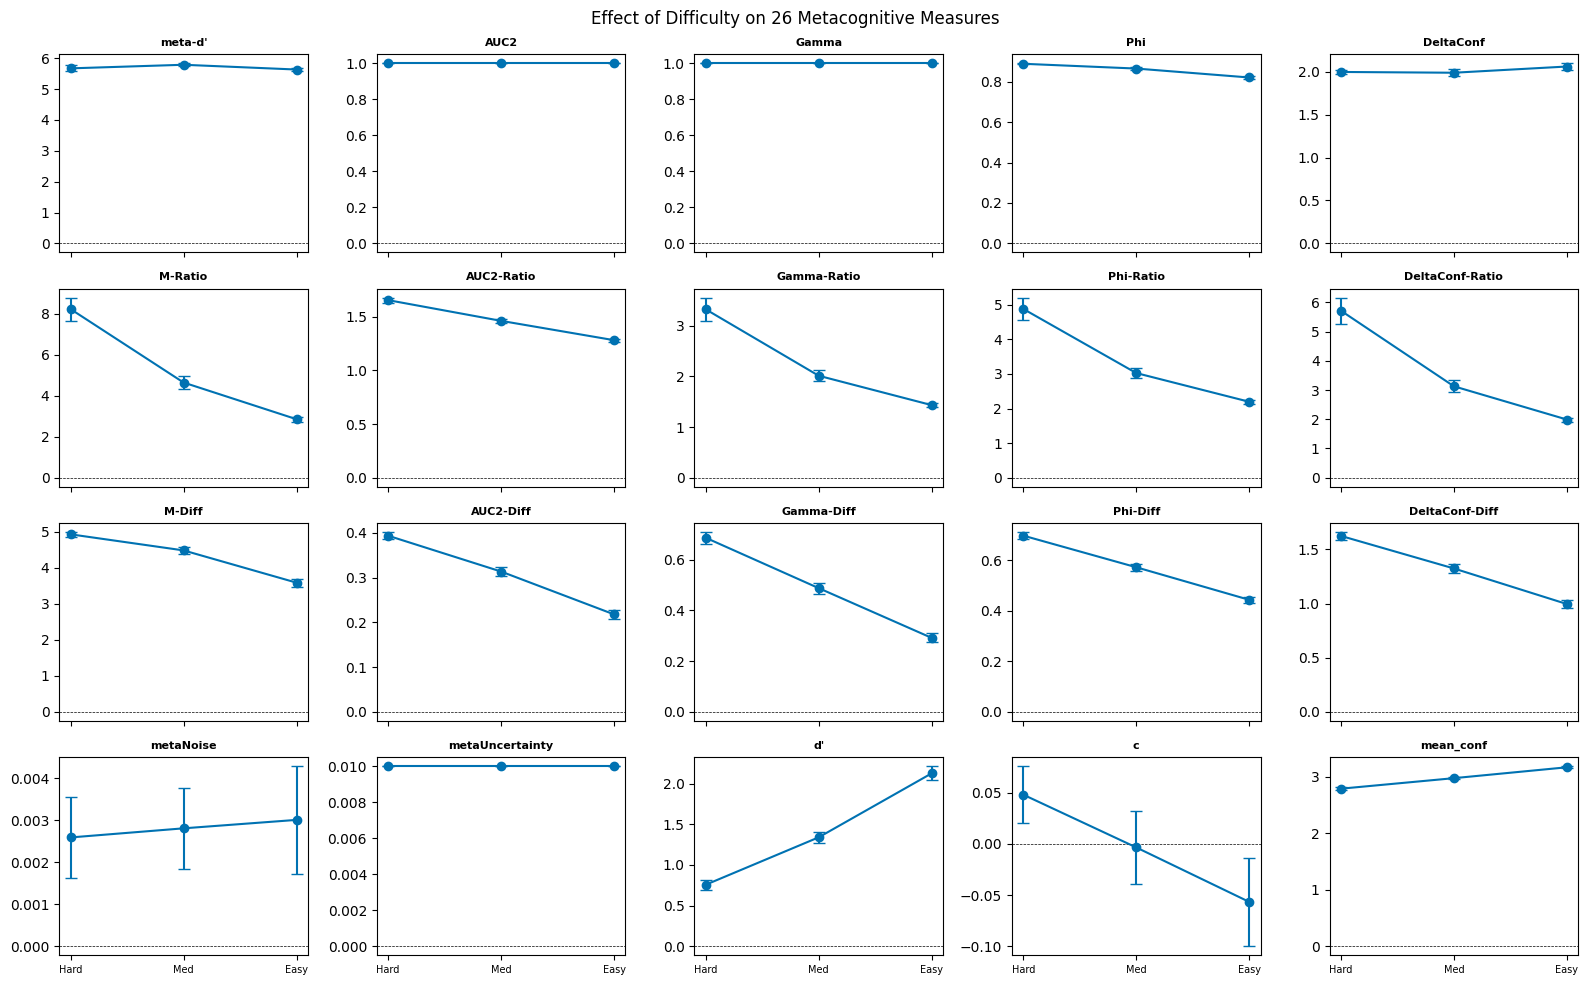

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharex=True)
axes = axes.flatten()
level_labels = ["Hard", "Med", "Easy"]

for m, (name, ax) in enumerate(zip(MEASURE_NAMES, axes)):
    col = clean[:, :, m]
    means = np.nanmean(col, axis=0)
    n_ok  = np.sum(~np.isnan(col), axis=0)
    sems  = np.nanstd(col, axis=0, ddof=1) / np.sqrt(np.maximum(n_ok, 1))
    ax.errorbar(range(n_levels), means, yerr=sems, marker="o", capsize=4, color="#0072b2")
    ax.set_title(name, fontsize=8, fontweight="bold")
    ax.set_xticks(range(n_levels))
    ax.set_xticklabels(level_labels, fontsize=7)
    ax.axhline(0, color="k", linewidth=0.5, linestyle="--")

plt.suptitle("Effect of Difficulty on 26 Metacognitive Measures", fontsize=12)
plt.tight_layout()
plt.show()
